# Gradient-Boosted Shot Quality Model

This notebook upgrades the Week 3 logistic regression baseline into an analysis-ready expected-shot-value model for the 2014-15 Kaggle shot log. The goal is to keep the same shot-quality framing, compare a boosted-tree model against the baseline on the same split, and then turn the boosted model into player- and team-level overperformance tables that can feed the Analysis section.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

# Let the notebook run whether it starts from the repo root or the notebook folder.
repo_root = Path.cwd().resolve()
if not (repo_root / 'src').exists():
    for candidate_root in repo_root.parents:
        if (candidate_root / 'src').exists():
            repo_root = candidate_root
            break

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.features.kaggle_shot_quality import (
    CATEGORICAL_FEATURES,
    MODEL_COLUMNS,
    NUMERIC_FEATURES,
    PLAYER_NAME_COLUMN,
    TARGET_COLUMN,
    TEAM_COLUMN,
    build_modeling_frame,
    build_residual_table,
    load_kaggle_shot_logs,
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)


In [2]:
raw_shots = load_kaggle_shot_logs()
modeling_shots = build_modeling_frame(raw_shots)

missing_shot_clock_rows = int(modeling_shots['SHOT_CLOCK'].isna().sum())

print(f'Raw Kaggle rows: {len(raw_shots):,}')
print(f'Modeling rows retained: {len(modeling_shots):,}')
print(f'Missing SHOT_CLOCK values kept for imputation: {missing_shot_clock_rows:,}')
print(f'Rows above 100K floor: {len(modeling_shots) > 100_000}')

modeling_shots[[PLAYER_NAME_COLUMN, TEAM_COLUMN, 'SHOT_RESULT', 'SHOT_CLOCK', 'SHOT_DIST', 'CLOSE_DEF_DIST']].head()


Raw Kaggle rows: 128,069
Modeling rows retained: 128,069
Missing SHOT_CLOCK values kept for imputation: 5,567
Rows above 100K floor: True


,player_name,SHOOTING_TEAM,SHOT_RESULT,SHOT_CLOCK,SHOT_DIST,CLOSE_DEF_DIST
0,brian roberts,CHA,made,10.8,7.7,1.3
1,brian roberts,CHA,missed,3.4,28.2,6.1
2,brian roberts,CHA,missed,NaN,10.1,0.9
3,brian roberts,CHA,missed,10.3,17.2,3.4
4,brian roberts,CHA,missed,10.9,3.7,1.1


In [3]:
target_breakdown = (
    modeling_shots['SHOT_RESULT']
    .value_counts()
    .rename_axis('SHOT_RESULT')
    .reset_index(name='count')
)
target_breakdown['share'] = target_breakdown['count'] / len(modeling_shots)

target_breakdown


,SHOT_RESULT,count,share
0,missed,70164,0.547861
1,made,57905,0.452139


In [4]:
model_features = modeling_shots[MODEL_COLUMNS].copy()
shot_outcomes = modeling_shots[TARGET_COLUMN].copy()

X_train, X_test, y_train, y_test = train_test_split(
    model_features,
    shot_outcomes,
    test_size=0.2,
    random_state=42,
    stratify=shot_outcomes,
)

print(f'Train rows: {len(X_train):,}')
print(f'Test rows: {len(X_test):,}')
print('Numeric features:', NUMERIC_FEATURES)
print('Categorical features:', CATEGORICAL_FEATURES)


Train rows: 102,455
Test rows: 25,614
Numeric features: ['FINAL_MARGIN', 'SHOT_NUMBER', 'PERIOD', 'SHOT_CLOCK', 'DRIBBLES', 'TOUCH_TIME', 'SHOT_DIST', 'CLOSE_DEF_DIST', 'GAME_CLOCK_SECONDS']
Categorical features: ['LOCATION', 'W', 'PTS_TYPE', 'SHOT_DIST_ZONE', 'TOUCH_TIME_BUCKET', 'LATE_CLOCK']


In [5]:
# Logistic regression stays here as the baseline reference point.
logistic_preprocessor = ColumnTransformer([
    (
        'num',
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]),
        NUMERIC_FEATURES,
    ),
    (
        'cat',
        Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]),
        CATEGORICAL_FEATURES,
    ),
])

# The boosted-tree model can work directly on imputed numeric values.
tree_preprocessor = ColumnTransformer([
    (
        'num',
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
        ]),
        NUMERIC_FEATURES,
    ),
    (
        'cat',
        Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]),
        CATEGORICAL_FEATURES,
    ),
])

baseline_logistic_model = Pipeline([
    ('preprocessor', logistic_preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, solver='lbfgs')),
])

boosted_shot_quality_model = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('classifier', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        reg_lambda=1.0,
        random_state=42,
        tree_method='hist',
        n_jobs=4,
    )),
])


In [6]:
def fit_and_score_model(model_name, model_pipeline, X_train, X_test, y_train, y_test):
    trained_model = clone(model_pipeline)
    trained_model.fit(X_train, y_train)

    predicted_labels = trained_model.predict(X_test)
    predicted_make_probabilities = trained_model.predict_proba(X_test)[:, 1]

    return {
        'model': model_name,
        'accuracy': accuracy_score(y_test, predicted_labels),
        'roc_auc': roc_auc_score(y_test, predicted_make_probabilities),
        'classification_report': classification_report(y_test, predicted_labels, digits=4),
        'predicted_labels': predicted_labels,
        'predicted_make_probabilities': predicted_make_probabilities,
        'trained_model': trained_model,
    }

baseline_results = fit_and_score_model(
    'logistic_regression',
    baseline_logistic_model,
    X_train,
    X_test,
    y_train,
    y_test,
)
boosted_results = fit_and_score_model(
    'xgboost',
    boosted_shot_quality_model,
    X_train,
    X_test,
    y_train,
    y_test,
)

metric_summary = pd.DataFrame([
    {
        'model': model_results['model'],
        'accuracy': model_results['accuracy'],
        'roc_auc': model_results['roc_auc'],
        'train_rows': len(X_train),
        'test_rows': len(X_test),
        'modeling_rows': len(modeling_shots),
        'feature_columns': len(MODEL_COLUMNS),
    }
    for model_results in (baseline_results, boosted_results)
]).sort_values('roc_auc', ascending=False)

metric_summary


,model,accuracy,roc_auc,train_rows,test_rows,modeling_rows,feature_columns
1,xgboost,0.619505,0.643554,102455,25614,128069,15
0,logistic_regression,0.613258,0.634716,102455,25614,128069,15


In [7]:
for model_results in (baseline_results, boosted_results):
    print('=' * 80)
    print(model_results['model'])
    print(f"Accuracy: {model_results['accuracy']:.4f}")
    print(f"ROC-AUC: {model_results['roc_auc']:.4f}")
    print(model_results['classification_report'])


logistic_regression
Accuracy: 0.6133
ROC-AUC: 0.6347
              precision    recall  f1-score   support

           0     0.6165    0.7783    0.6880     14033
           1     0.6061    0.4133    0.4914     11581

    accuracy                         0.6133     25614
   macro avg     0.6113    0.5958    0.5897     25614
weighted avg     0.6118    0.6133    0.5991     25614

xgboost
Accuracy: 0.6195
ROC-AUC: 0.6436
              precision    recall  f1-score   support

           0     0.6106    0.8434    0.7083     14033
           1     0.6472    0.3482    0.4528     11581

    accuracy                         0.6195     25614
   macro avg     0.6289    0.5958    0.5806     25614
weighted avg     0.6272    0.6195    0.5928     25614



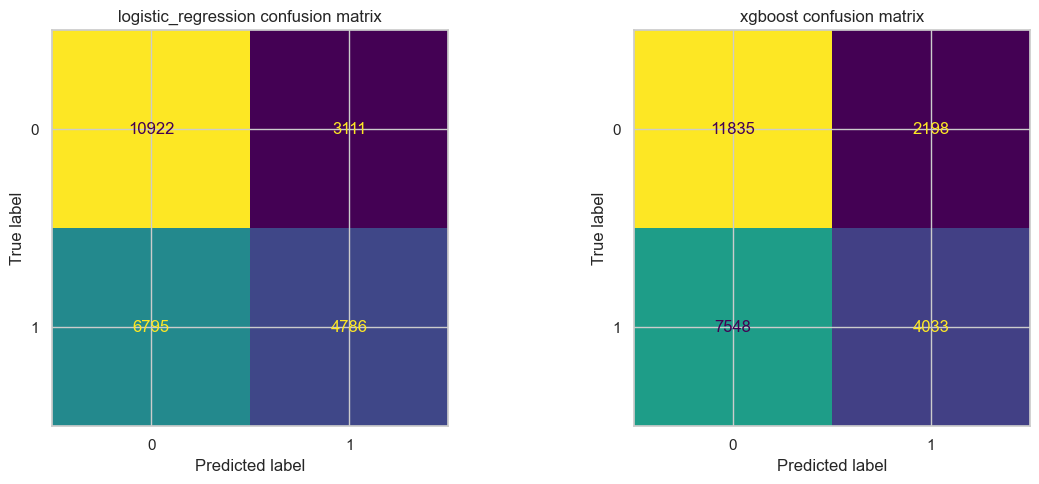

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, model_results in zip(axes, (baseline_results, boosted_results), strict=False):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        model_results['predicted_labels'],
        ax=ax,
        colorbar=False,
    )
    ax.set_title(f"{model_results['model']} confusion matrix")

plt.tight_layout()
plt.show()


In [9]:
boosted_feature_names = boosted_results['trained_model'].named_steps['preprocessor'].get_feature_names_out()
boosted_feature_importance = pd.DataFrame({
    'feature': boosted_feature_names,
    'importance': boosted_results['trained_model'].named_steps['classifier'].feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

boosted_feature_importance.head(15)


,feature,importance
0,cat__SHOT_DIST_ZONE_at_rim,0.649427
1,cat__SHOT_DIST_ZONE_three_plus,0.053628
2,num__SHOT_DIST,0.038760
3,cat__TOUCH_TIME_BUCKET_quick,0.035486
4,num__CLOSE_DEF_DIST,0.025226
5,cat__SHOT_DIST_ZONE_short_midrange,0.020695
6,cat__W_L,0.018419
7,cat__LATE_CLOCK_late_clock,0.015467
8,cat__PTS_TYPE_2,0.014814
9,cat__SHOT_DIST_ZONE_long_midrange,0.014318


In [10]:
# Refit the boosted model on the full Kaggle season so the residual tables use every shot.
full_season_boosted_model = clone(boosted_shot_quality_model)
full_season_boosted_model.fit(model_features, shot_outcomes)

scored_shots = modeling_shots[[PLAYER_NAME_COLUMN, TEAM_COLUMN, 'SHOT_RESULT', TARGET_COLUMN]].copy()
scored_shots['EXPECTED_MAKE_PROB'] = full_season_boosted_model.predict_proba(model_features)[:, 1]

player_residuals = build_residual_table(scored_shots, PLAYER_NAME_COLUMN, min_shots=150)
team_residuals = build_residual_table(scored_shots, TEAM_COLUMN, min_shots=2000)

player_residuals.head(15)


,player_name,shots,actual_makes,expected_makes,actual_fg_pct,expected_fg_pct,makes_above_expected,fg_pct_above_expected
0,chris paul,885,425,373.526215,0.480226,0.422064,51.473785,0.058162
1,kyle korver,478,235,189.884323,0.491632,0.397248,45.115677,0.094384
2,nikola vucevic,902,480,439.607605,0.532151,0.487370,40.392395,0.044781
3,stephen curry,968,470,431.557312,0.485537,0.445824,38.442688,0.039714
4,dirk nowtizski,816,377,342.676239,0.462010,0.419946,34.323761,0.042063
5,joe johnson,767,335,301.078308,0.436767,0.392540,33.921692,0.044226
6,anthony davis,841,457,424.792908,0.543401,0.505105,32.207092,0.038296
7,james johnson,311,191,159.673904,0.614148,0.513421,31.326096,0.100727
8,chris bosh,745,343,312.915833,0.460403,0.420021,30.084167,0.040381
9,lebron james,978,478,448.722992,0.488753,0.458817,29.277008,0.029936


In [11]:
print('Top player overperformers')
display(player_residuals.head(10))

print('Top player underperformers')
display(player_residuals.tail(10).sort_values('makes_above_expected'))

print('Top team overperformers')
display(team_residuals.head(10))

print('Top team underperformers')
display(team_residuals.tail(10).sort_values('makes_above_expected'))


Top player overperformers


,player_name,shots,actual_makes,expected_makes,actual_fg_pct,expected_fg_pct,makes_above_expected,fg_pct_above_expected
0,chris paul,885,425,373.526215,0.480226,0.422064,51.473785,0.058162
1,kyle korver,478,235,189.884323,0.491632,0.397248,45.115677,0.094384
2,nikola vucevic,902,480,439.607605,0.532151,0.487370,40.392395,0.044781
3,stephen curry,968,470,431.557312,0.485537,0.445824,38.442688,0.039714
4,dirk nowtizski,816,377,342.676239,0.462010,0.419946,34.323761,0.042063
5,joe johnson,767,335,301.078308,0.436767,0.392540,33.921692,0.044226
6,anthony davis,841,457,424.792908,0.543401,0.505105,32.207092,0.038296
7,james johnson,311,191,159.673904,0.614148,0.513421,31.326096,0.100727
8,chris bosh,745,343,312.915833,0.460403,0.420021,30.084167,0.040381
9,lebron james,978,478,448.722992,0.488753,0.458817,29.277008,0.029936


Top player underperformers


,player_name,shots,actual_makes,expected_makes,actual_fg_pct,expected_fg_pct,makes_above_expected,fg_pct_above_expected
265,trevor ariza,683,259,302.808289,0.379209,0.443350,-43.808289,-0.064141
264,tony allen,358,172,210.537918,0.480447,0.588095,-38.537918,-0.107648
263,tyreke evans,914,396,432.476379,0.433260,0.473169,-36.476379,-0.039909
262,andre drummond,665,338,373.297241,0.508271,0.561349,-35.297241,-0.053079
261,omer asik,300,152,186.742081,0.506667,0.622474,-34.742081,-0.115807
260,joakim noah,340,149,180.976471,0.438235,0.532284,-31.976471,-0.094048
259,elfrid payton,480,198,227.422089,0.412500,0.473796,-29.422089,-0.061296
258,draymond green,552,242,271.188416,0.438406,0.491283,-29.188416,-0.052878
257,nerles noel,444,197,225.969894,0.443694,0.508941,-28.969894,-0.065248
256,zaza pachulia,350,151,177.767441,0.431429,0.507907,-26.767441,-0.076478


Top team overperformers


,SHOOTING_TEAM,shots,actual_makes,expected_makes,actual_fg_pct,expected_fg_pct,makes_above_expected,fg_pct_above_expected
0,LAC,4402,2045,1965.528687,0.464562,0.446508,79.471313,0.018053
1,TOR,4189,1941,1882.174927,0.463356,0.449314,58.825073,0.014043
2,MIN,3885,1842,1790.466431,0.474131,0.460867,51.533569,0.013265
3,BKN,4573,2109,2060.686768,0.461185,0.450620,48.313232,0.010565
4,NYK,3713,1683,1645.227539,0.453272,0.443099,37.772461,0.010173
5,LAL,4645,2121,2087.660400,0.456620,0.449443,33.339600,0.007178
6,CHA,4277,1906,1875.089966,0.445639,0.438412,30.910034,0.007227
7,WAS,4376,1999,1971.564331,0.456810,0.450540,27.435669,0.006270
8,PHX,4793,2165,2145.508057,0.451700,0.447634,19.491943,0.004067
9,CLE,4003,1847,1829.026733,0.461404,0.456914,17.973267,0.004490


Top team underperformers


,SHOOTING_TEAM,shots,actual_makes,expected_makes,actual_fg_pct,expected_fg_pct,makes_above_expected,fg_pct_above_expected
29,PHI,4132,1785,1886.995850,0.431994,0.456679,-101.995850,-0.024684
28,DET,3848,1693,1755.800903,0.439969,0.456289,-62.800903,-0.016320
27,SAS,4603,2035,2087.204102,0.442103,0.453444,-52.204102,-0.011341
26,OKC,4575,2042,2086.244385,0.446339,0.456010,-44.244385,-0.009671
25,CHI,4233,1886,1915.915405,0.445547,0.452614,-29.915405,-0.007067
24,GSW,4774,2132,2161.044678,0.446586,0.452670,-29.044678,-0.006084
23,IND,4615,2025,2052.160156,0.438787,0.444672,-27.160156,-0.005885
22,DEN,4374,1962,1983.169434,0.448560,0.453400,-21.169434,-0.004840
21,NOP,4111,1882,1902.963623,0.457796,0.462896,-20.963623,-0.005099
20,UTA,4146,1879,1898.250366,0.453208,0.457851,-19.250366,-0.004643


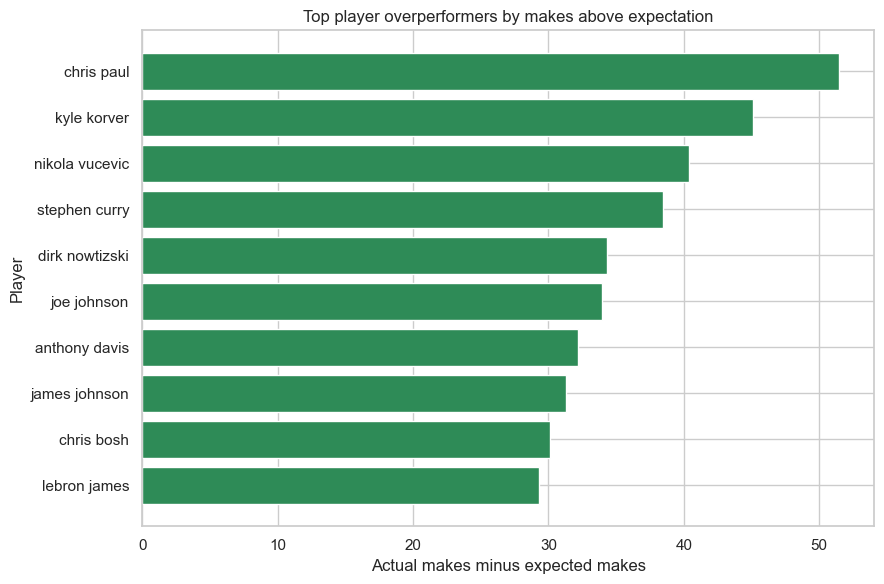

In [12]:
top_players = player_residuals.head(10).sort_values('makes_above_expected')

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_players[PLAYER_NAME_COLUMN], top_players['makes_above_expected'], color='seagreen')
ax.set_title('Top player overperformers by makes above expectation')
ax.set_xlabel('Actual makes minus expected makes')
ax.set_ylabel('Player')
plt.tight_layout()
plt.show()


In [13]:
analysis_handoff = pd.DataFrame({
    'item': [
        'model_used',
        'feature_set',
        'final_row_count',
        'baseline_accuracy',
        'baseline_roc_auc',
        'boosted_accuracy',
        'boosted_roc_auc',
    ],
    'value': [
        'XGBoost classifier with imputed numeric fields and one-hot categorical fields',
        ', '.join(MODEL_COLUMNS),
        len(modeling_shots),
        round(baseline_results['accuracy'], 4),
        round(baseline_results['roc_auc'], 4),
        round(boosted_results['accuracy'], 4),
        round(boosted_results['roc_auc'], 4),
    ],
})

analysis_handoff


,item,value
0,model_used,XGBoost classifier with imputed numeric fields...
1,feature_set,"FINAL_MARGIN, SHOT_NUMBER, PERIOD, SHOT_CLOCK,..."
2,final_row_count,128069
3,baseline_accuracy,0.6133
4,baseline_roc_auc,0.6347
5,boosted_accuracy,0.6195
6,boosted_roc_auc,0.6436


## Interpretation

- The modeling sample stays comfortably above the 100,000-observation floor even after adding derived features and keeping missing `SHOT_CLOCK` rows for imputation.
- The gradient-boosted model is the main Week 4 upgrade because it can capture nonlinear shot-quality patterns that the logistic baseline has to flatten into straight-line effects.
- The residual tables turn those shot-level probabilities into analysis-ready findings: who made more shots than the model expected, who fell short, and whether the same story appears at the team level.
- For the writeup, the cleanest framing is that the logistic notebook established a benchmark, while this boosted model becomes the expected-shot-value engine for the overperformer and rank-shift analysis.
